In [1]:
import pandas as pd 

In [2]:
df = pd.read_csv('Titanic.csv')

In [3]:
#3 
# Eliminar las columnas Unnamed: 0 y parch
step1 = df.drop(columns=['Unnamed: 0', 'parch'])

In [4]:
# Guardar en csv
step1.to_csv('STEP_1.csv', index=False)

In [ ]:
step1.info() #confirmamos cambios

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   fare         891 non-null    float64
 6   embarked     889 non-null    str    
 7   class        891 non-null    str    
 8   who          891 non-null    str    
 9   adult_male   891 non-null    bool   
 10  deck         203 non-null    str    
 11  embark_town  889 non-null    str    
 12  alive        891 non-null    str    
 13  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(3), str(7)
memory usage: 85.4 KB


In [ ]:
#4
# Crear copia 
step2 = step1.copy()

# a) Reemplazar nulos en age con 0
step2['age'] = step2['age'].fillna(0)

#Reemplazar nulos en embarked y embark_town con "unknown"
step2['embarked'] = step2['embarked'].fillna('unknown')
step2['embark_town'] = step2['embark_town'].fillna('unknown')

# Reemplazar nulos con "U"
step2['deck'] = step2['deck'].fillna('U')

# Guardar en archivo CSV
step2.to_csv('STEP_2.csv', index=False)

In [ ]:
step2.info() #confirmammos cambios 

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          891 non-null    float64
 4   sibsp        891 non-null    int64  
 5   fare         891 non-null    float64
 6   embarked     891 non-null    str    
 7   class        891 non-null    str    
 8   who          891 non-null    str    
 9   adult_male   891 non-null    bool   
 10  deck         891 non-null    str    
 11  embark_town  891 non-null    str    
 12  alive        891 non-null    str    
 13  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(3), str(7)
memory usage: 85.4 KB


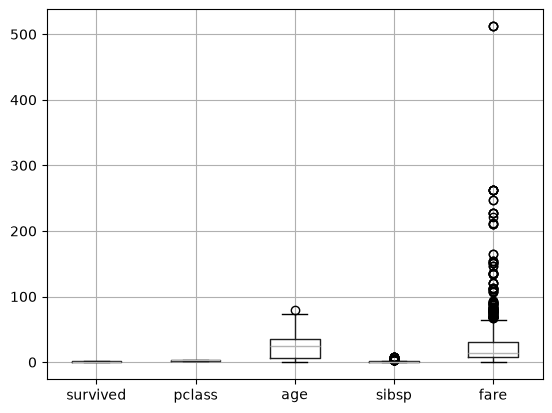

In [ ]:
# 5
df2 = pd.read_csv('STEP_2.csv')

# Definir columnas numéricas
num_cols = ['survived', 'pclass', 'age', 'sibsp', 'fare']

# Graficar diagrama de caja
df2[num_cols].boxplot()

# Crear copia
df3 = df2.copy()

# Reemplazar outliers usando IQR
for col in num_cols:
    q1 = df3[col].quantile(0.25)
    q3 = df3[col].quantile(0.75)
    iqr = q3 - q1
    
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    
    # Reemplazo directo
    outliers = (df3[col] < lim_inf) | (df3[col] > lim_sup)
    df3.loc[outliers, col] = df3[col].median()

# Guardar el archivo final
df3.to_csv('STEP_3.csv', index=False)

In [ ]:
# 6
df3 = pd.read_csv('STEP_3.csv')

# Variable: pclass
print("analisis: pclass")
print(df3['pclass'].value_counts())
df3['pclass'].value_counts().plot(kind='bar', title='Frecuencia de pclass')

# Variable: sex
print("analisis: sex")
print(df3['sex'].value_counts())
df3['sex'].value_counts().plot(kind='bar', title='Frecuencia de sex')

# Variable: age
print("analisis: age")
print(df3['age'].describe())
df3['age'].plot(kind='hist', title='Distribución de age')

# Variable: fare
print("analisis: fare")
print(df3['fare'].describe())
df3['fare'].plot(kind='hist', title='Distribución de fare')

# Variable: embark_town
print("analisis: embark_town")
print(df3['embark_town'].value_counts())
df3['embark_town'].value_counts().plot(kind='bar', title='Frecuencia de embark_town')

# Variable: alive
print("analisis: alive")
print(df3['alive'].value_counts())
df3['alive'].value_counts().plot(kind='bar', title='Frecuencia de alive')

analisis: pclass
pclass
3    491
1    216
2    184
Name: count, dtype: int64
analisis: sex
sex
male      577
female    314
Name: count, dtype: int64
analisis: age
count    891.000000
mean      23.736442
std       17.494828
min        0.000000
25%        6.000000
50%       24.000000
75%       35.000000
max       74.000000
Name: age, dtype: float64
analisis: fare
count    891.000000
mean      17.383622
std       12.713016
min        0.000000
25%        7.910400
50%       14.454200
75%       24.150000
max       65.000000
Name: fare, dtype: float64
analisis: embark_town
embark_town
Southampton    644
Cherbourg      168
Queenstown      77
unknown          2
Name: count, dtype: int64
analisis: alive
alive
no     549
yes    342
Name: count, dtype: int64


<Axes: title={'center': 'Frecuencia de alive'}, xlabel='alive', ylabel='Frequency'>

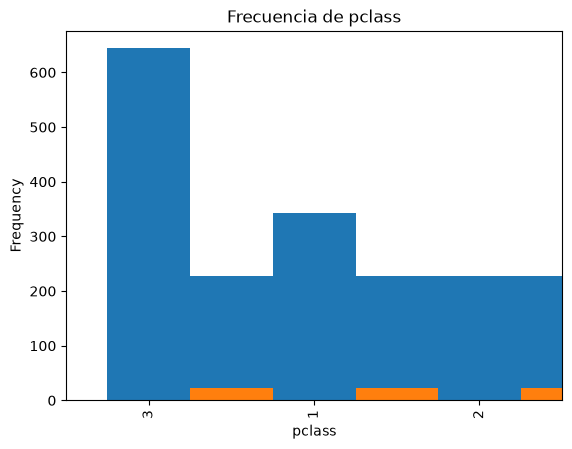

In [ ]:
# Gráfica de pclass
g1 = df3['pclass'].value_counts().plot(kind='bar', title='Frecuencia de pclass')
g1.figure


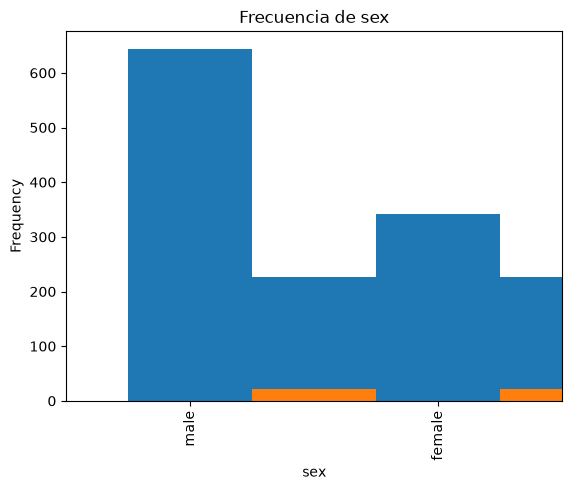

In [ ]:
# Gráfica de sex
g2 = df3['sex'].value_counts().plot(kind='bar', title='Frecuencia de sex')
g2.figure

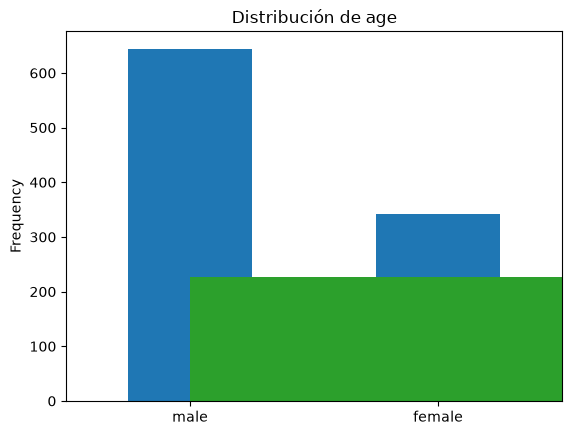

In [38]:
# Gráfica de age
g3 = df3['age'].plot(kind='hist', title='Distribución de age')
g3.figure

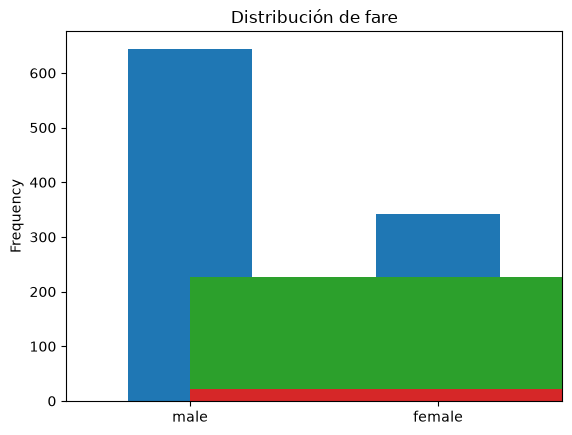

In [ ]:
# Gráfica de fare
g4 = df3['fare'].plot(kind='hist', title='Distribución de fare')
g4.figure

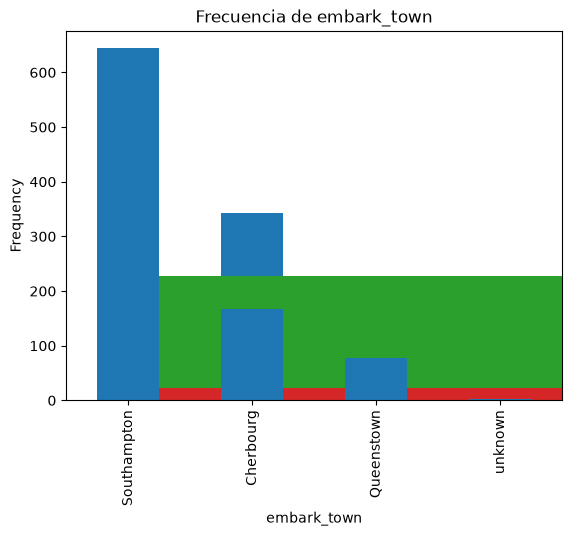

In [40]:
# Gráfica de embark_town
g5 = df3['embark_town'].value_counts().plot(kind='bar', title='Frecuencia de embark_town')
g5.figure

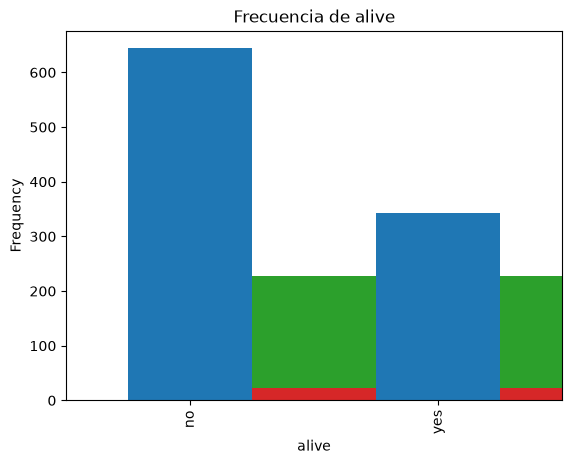

In [ ]:
# Gráfica de alive
g6 = df3['alive'].value_counts().plot(kind='bar', title='Frecuencia de alive')
g6.figure